# MITGCM Transect Forcing Analysis Plotting

**Purpose**: Code for plotting the decorrelation time scale along a transect off the  coast of southern california. 

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook

In [1]:
%matplotlib inline

Import python libraries

In [2]:
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
from netCDF4 import Dataset, num2date
from datetime import datetime
import os
import cmocean.cm as cmo
from geopy.distance import geodesic
import matplotlib.gridspec as gridspec

# Set path to access python functions
ROOT = '/Users/lukecolosi/Desktop/projects/graduate_research/Gille_lab/'
sys.path.append(ROOT + 'AirSeaCoupling/tools/')

#--- Other Functions ---# 
from plotScaleAnalysis import add_freq_marker

Set plotting parameters

In [43]:
# Set time and space parameters
lat_bnds     = [33, 35]                      # Specifies the latitude bounds for the region to analyze
lon_bnds     = [-123 % 360, -120 % 360]      # Specifies the longitude bounds for the region to analyze

# Set path to project directory
PATH = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/temporal/'
PATH_mld = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/transect/'
PATH_grad = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/transect/'
PATH_forcing = ROOT + 'AirSeaCoupling/data/mitgcm/SWOT_MARA_RUN4_LY/spatial/regional/'
PATH_figs =  ROOT + 'AirSeaCoupling/figs/paper_figures/'

# Set font and fontsize
os.environ["PATH"] = "/usr/local/texlive/2022/bin/universal-darwin:" + os.environ["PATH"]
fontsize = 15
plt.rcParams.update({
    "font.size": fontsize,         # Fontsize
    "text.usetex": True,           # Use LaTeX for all text
    "font.family": "serif",        # Optional: match LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: load extra LaTeX packages
}) 

Load in mix layer depth and decorrelation scales along the transect

In [4]:
#-------------------------------------------------------#
# Mixed Layer depth Data
#-------------------------------------------------------#
filename_mld  = PATH + "/mitgcm_transect_mld_climatology.npz"

# Load data 
ds_mld   = np.load(filename_mld, allow_pickle=True)

# Extract data variables
mld                  = ds_mld['mld']                 # Units: meters
mld_monthly_mean     = ds_mld['mld_monthly_mean']    # Units: meters
mld_monthly_var      = ds_mld['mld_monthly_var']     # Units: meters
mld_monthly_stdm     = ds_mld['mld_monthly_stdm'] 
mld_monthly_stdv     = ds_mld['mld_monthly_stdv'] 
lat                  = ds_mld['lat'] 
lon                  = ds_mld['lon'] 
time_mld             = ds_mld['time']
time_mld_monthly     = ds_mld['time_monthly']

#-------------------------------------------------------#
# Decorrelation scale Data
#-------------------------------------------------------#
filename_decor  = PATH + "/mitgcm_transect_temporal_scale_densityCalCOFI_line80_unc.npz"

# Load data 
ds_decor   = np.load(filename_decor, allow_pickle=True)

# Extract data variables
Lt_days       = ds_decor['Lt_days']         # Units: days
Lt_stdm_days  = ds_decor['Lt_stdm_days']    # Units: days
dist          = ds_decor['dist']            # Units: kilometers
depth         = ds_decor['depth']

#-------------------------------------------------------#
# Wind Stress Data
#-------------------------------------------------------#
filename_ws  = PATH_forcing + "mitgcm_transect_wind_stress_stats_CalCOFI_line80.npz"

# Load data 
ds_ws   = np.load(filename_ws, allow_pickle=True)

# Extract data variables
tau_curl_trans   = ds_ws['tau_curl_trans']    
tau_curl_median  = ds_ws['tau_curl_median_all']      
tau_curl_mean    = ds_ws['tau_curl_mean_all']  
tau_curl_stdm    = ds_ws['tau_curl_stdm_all'] 
tau_curl_var     = ds_ws['tau_curl_var_all']   
tau_curl_stdv    = ds_ws['tau_curl_stdv_all'] 
dist_ws          = ds_ws['dist_c']            
lon_ws           = ds_ws['lon']
lat_ws           = ds_ws['lat']

#-------------------------------------------------------#
# Heat Flux Data
#-------------------------------------------------------#
filename_hf  = PATH_forcing + "mitgcm_transect_heat_flux_stats_CalCOFI_line80.npz"

# Load data 
ds_hf   = np.load(filename_hf, allow_pickle=True)

# Extract data variables
Q_nonsw_trans    = ds_hf['Q_nonsw_trans']         
Q_nonsw_mean     = ds_hf['Q_nonsw_mean_all']  
Q_nonsw_stdm     = ds_hf['Q_nonsw_stdm_all'] 
Q_nonsw_var      = ds_hf['Q_nonsw_var_all']   
Q_nonsw_stdv     = ds_hf['Q_nonsw_stdv_all']   
dist_hf          = ds_hf['dist_c']            
lon_hf           = ds_hf['lon']
lat_hf           = ds_hf['lat']

#-------------------------------------------------------#
# Spatial Gradient Analysis Data
#-------------------------------------------------------#
filename_grad = PATH_grad + "/mitgcm_transect_spatial_gradients.npz"

# Load data 
ds_grad   = np.load(filename_grad, allow_pickle=True)

# Extract data variables
u_along_bar_mean       = ds_grad['u_along_bar_mean']
u_cross_bar_mean       = ds_grad['u_cross_bar_mean']
u_along_mean           = ds_grad['u_along_mean']
u_cross_mean           = ds_grad['u_cross_mean']
drho_dx_mean           = ds_grad['drho_dx_mean']      

#-------------------------------------------------------#
# Stratification Data
#-------------------------------------------------------#
filename_tsd = PATH + "mitgcm_intermediate_data_TSD_hrly_transect_profiles.nc"
nc_tsd = Dataset(filename_tsd, 'r')

# Extract data variables
depth_mid = nc_tsd.variables['depth_mid'][:]
dist_nz      = nc_tsd.variables['DIST'][:]    
Nz  = nc_tsd.variables['NZ'][:] 

# Flip the distance axis of the data array to match the orientation of the distance coordinates (increasing from left to right)
Nz = Nz[::-1,:]

#-------------------------------------------------------#
# Ocean Bottom Data
#-------------------------------------------------------#

# Set filename and read in netcdf file
filename = PATH_mld + "ocean_bottom_CCS4_transect_calCOFI_line80.nc"
nc = Dataset(filename, 'r')

# Extract data variables
dist_b = nc.variables['distance'][:]
bottom_depth = nc.variables['bottom_depth'][:]

# Reverse order of bottom depth 
bottom_depth = bottom_depth[::-1]

Slice the data so that the analysis only considers offshore distances up to 123 degrees west

In [5]:
# Find the indices for the upper 200 meters and specified lat and lon bounds
dist_mask = ((lat >= lat_bnds[0]) & (lat <= lat_bnds[1]) & (lon >= lon_bnds[0]) & (lon <= lon_bnds[1]))
idx_dist  = np.where(dist_mask)[0]

# Extract indices for upper 200 meters and specified lat and lon bounds
lat          = lat[idx_dist]
lon          = lon[idx_dist]
bottom_depth = bottom_depth[idx_dist]
mld          = mld[idx_dist,:]
mld_monthly_mean = mld_monthly_mean[idx_dist,:]

Compute cumulative distance along line 80.0 the mixed layer depth 

In [6]:
# Initialize array 
dist_mld = np.zeros(len(lon))

# Loop through stations 
for i in range(1,len(lon)): 

    # Define i and i + 1 points along transect
    pt1 = (lat[i-1], lon[i-1])
    pt2 = (lat[i],   lon[i])

    # Compute distance in kilometers along transect
    dist_mld[i] = dist_mld[i-1] + geodesic(pt1, pt2).km

Set the locations of each cce mooring

In [7]:
#--- CCE 1 ---# 
lon1 = -122.52233 
lat1 = 33.457

#--- CCE 2 ---# 
lon2 = -120.8042 
lat2 = 34.3075

#--- CCE 3 ---# 
lon3 = -120.53816
lat3 = 34.448512

#--- Shore ---# 
lon_shore = -120.483310
lat_shore = 34.482942

Compute the distance from the final CalCOFI station (closest to shore) and the shore

In [8]:
# Define points 
calcofi_station = (lat[0], lon[0])
shore           = (lat_shore,   lon_shore)

# Compute distance
dist_offset = geodesic(calcofi_station, shore).km

# Apply distance from shore correction
dist_cor     = dist + dist_offset
dist_ws_cor  = dist_ws + dist_offset
dist_hf_cor  = dist_hf + dist_offset
dist_mld_cor = dist_mld + dist_offset

Compute the relative uncertainty and mask grid point with a decorrelation scale less than twice its standard error

In [9]:
# Set noise to signal ratio criteria
ns = 10 / 10

# Compute spatial means 
Lt_rho_spatial_mean = np.mean(Lt_days) 

# Compute the relative uncertainty
Lt_rho_rel_unc = Lt_stdm_days / (Lt_days - Lt_rho_spatial_mean)

# Mask not statistically significant grid points
Lt_rho_mask = np.ma.getmask(np.ma.masked_greater_equal(Lt_rho_rel_unc, (ns)))

# Create a mask array where non-significant points = 1, others = NaN
rho_mask = np.where(Lt_rho_mask, 1, np.nan)

Compute the seasonally averaged mixed layer depth 

In [10]:
mld_mean = np.mean(mld_monthly_mean,axis=1)
mld_std  = np.std(mld_monthly_mean,ddof=1,axis=1)

Compute the depth averaged decorrelation time scale for the upper 15 meters

In [66]:
# Set the depth threshold and positive downward depth array
z_o   = 10             # Depth threshold (units: meters)
z_pos = np.abs(depth)  # Positive downward depth array

# Find indices for depths shallower than z_o 
idx_depth = np.where(z_pos <= z_o)[0]

# Compute depth steps for weighted mean calculation
dz = np.gradient(z_pos)

# Compute weighted mean of decorrelation time scale for depths shallower than z_o 
Lt_days_mean = np.average(Lt_days[:,idx_depth], weights=dz[idx_depth], axis = 1)

Mask zeros in Lt_days_mean 

In [67]:
Lt_days_mean = np.ma.masked_where(Lt_days_mean == 0, Lt_days_mean)

Plot the wind stress, heat flux, and decorrelation time scale in the upper ocean 

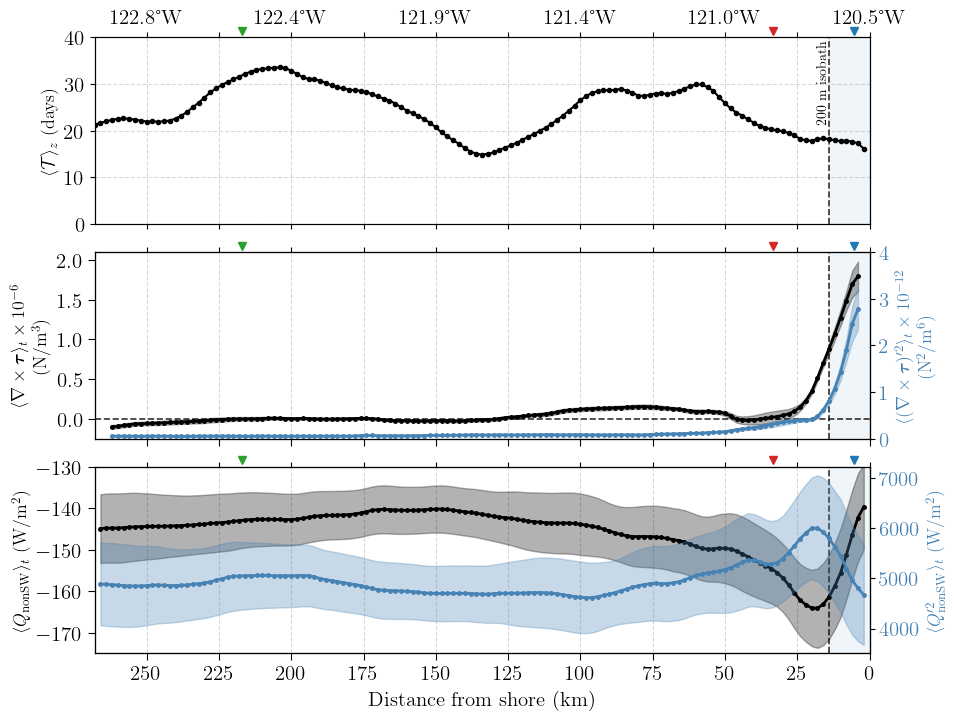

In [71]:
# Set plotting parameters
x_max = np.max([dist[-1],dist_ws[-1], dist_hf[-1] ])

# Set the index of the coastline (where bottom depth is closest to 200 m)
idx_coast = np.argmin(np.abs(np.abs(bottom_depth) - 200))

# Create figure
fig, axes = plt.subplots(3,1,figsize=(10,8))

#--- Subplot 1 ---# 
ax = axes[0]

# Shade the coastal ocean (coastline to 200m isobath)
ax.axvspan(0, dist_b[idx_coast], alpha=0.08, color='steelblue')
ax.axvline(x=dist_b[idx_coast], color='k', linewidth=1.2, linestyle='--', alpha=0.8)

# Add label for 200 m isobath
ax.text(dist_b[idx_coast] + 4, 0.985, '200 m isobath', 
        transform=ax.get_xaxis_transform(),
        ha='left', va='top', fontsize=10, color='k', rotation=90)

# Plot depth-averaged decorrelation time scale 
ax.plot(dist, Lt_days_mean, color='k', lw = 1.5, linestyle='-', marker='.')

# Set axis attributes
ax.set_ylabel(r'$\langle \mathcal{T} \rangle_z$ (days)', fontsize=13)
ax.set_xlim(0,x_max)
ax.set_ylim(0,40)
ax.set_xticks(np.arange(0,250+25,25))
ax.invert_xaxis()
ax.grid(linestyle='--',alpha=0.3,color='grey')

# --- Set top longitude axis --- # 
ax_top = ax.twiny()

# Set  limits of top axis and reverse order 
ax_top.set_xlim(0, x_max)
ax_top.invert_xaxis()

# Obtain distance ticks from bottom axis
dist_ticks = ax.get_xticks()

# Interpolate longitude ticks at the position of the bottom axis tick positions
lon_180 = ((lon + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist, lon_180)

# Set the ticklabels on the longitude ticks for the top axis
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set the ticks location and tick labels for the top axis
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels)

# Sort lon so it is monotonically increasing for interpolation 
sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist[sort_idx]

# Interpolate the position of each mooring onto distance from shore
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

add_freq_marker(ax, dist1, '', y_marker=1.035, y_text=1.035, fontsize=14,
                markerfacecolor='tab:green', markeredgecolor='tab:green')
add_freq_marker(ax, dist2, '', y_marker=1.035, y_text=1.035, fontsize=14,
                markerfacecolor='tab:red', markeredgecolor='tab:red')
add_freq_marker(ax, dist3, '', y_marker=1.035, y_text=1.035, fontsize=14,
                markerfacecolor='tab:blue', markeredgecolor='tab:blue')

# Remove bottom x-axis ticklabels
ax.set_xticklabels([])

#--- Subplot 2 ---# 
ax = axes[1]

# Twin the axis for variance 
ax_twin = ax.twinx()

#--- Axis 1: Mean Wind Stress Curl ---# 

# Shade the coastal ocean (coastline to 200m isobath)
ax.axvspan(0, dist_b[idx_coast], alpha=0.08, color='steelblue')
ax.axvline(x=dist_b[idx_coast], color='k', linewidth=1.2, linestyle='--', alpha=0.8)

# Plot horizontal line for zero crossing
ax.axhline(0, color='k', linewidth=1.2, linestyle='--', alpha=0.8)

# Plot the mean wind stress curl for each season
ax.plot(dist_ws, tau_curl_mean*10**6, '.-', color='k', linewidth=2, label='All Seasons', zorder=4, markersize=5)

# Plot the standard error of the mean as shaded area around the mean
ax.fill_between(dist_ws, tau_curl_mean*10**6 - tau_curl_stdm*10**6, tau_curl_mean*10**6 + tau_curl_stdm*10**6, color='k', alpha=0.3, zorder=3)

# Set axis attributes
ax.set_ylabel(r'$\langle \nabla \times \boldsymbol{\tau} \rangle_t \times 10^{-6}$' + "\n" + r'(N/m$^3$)', fontsize=13)
ax.set_xticks(np.arange(0, 250+25, 25))
ax.set_yticks(np.arange(0,2+0.5, 0.5))
ax.set_xlim(0, x_max)
ax.set_ylim(-0.25, 2.1)
ax.invert_xaxis()
ax.grid(axis= 'x', linestyle='--', alpha=0.3, color='grey')
ax.tick_params(which='both', direction='out', top=True, right=False, left=True, bottom=True, length=5)

#--- Axis 2: Variance Wind Stress Curl ---# 

# Plot the mean wind stress curl for each season
ax_twin.plot(dist_ws, tau_curl_var*10**12, '.-', color='steelblue', linewidth=2, label='All Seasons', markersize=5)

# Plot the standard error of the variance as shaded area around the mean
ax_twin.fill_between(dist_ws, tau_curl_var*10**12 - tau_curl_stdv*10**12, tau_curl_var*10**12 + tau_curl_stdv*10**12, color='steelblue', alpha=0.3, zorder=3)

# Set axis attributes
ax_twin.set_ylabel(r"$\langle (\nabla \times \boldsymbol{\tau})'^2 \rangle_t \times 10^{-12}$" + "\n" + r"(N$^2$/m$^6$)", color='steelblue', fontsize=13)
ax_twin.tick_params(axis='y', labelcolor='steelblue', labelsize=fontsize)
ax_twin.set_ylim(0, 4)

# --- Set top longitude axis --- # 
ax_top = ax.twiny()

# Set  limits of top axis and reverse order 
ax_top.set_xlim(0, x_max)
ax_top.invert_xaxis()

# Obtain distance ticks from bottom axis
dist_ticks = ax.get_xticks()

# Interpolate longitude ticks at the position of the bottom axis tick positions
lon_180 = ((lon_ws + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist_ws, lon_180)

# Set the ticklabels on the longitude ticks for the top axis
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set the ticks location and tick labels for the top axis
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels)

# Sort lon so it is monotonically increasing for interpolation 
sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist_ws[sort_idx]

# Interpolate the position of each mooring onto distance from shore
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

add_freq_marker(ax, dist1, '', y_marker=1.035, y_text=1.035, fontsize=14,
                markerfacecolor='tab:green', markeredgecolor='tab:green')
add_freq_marker(ax, dist2, '', y_marker=1.035, y_text=1.035, fontsize=14,
                markerfacecolor='tab:red', markeredgecolor='tab:red')
add_freq_marker(ax, dist3, '', y_marker=1.035, y_text=1.035, fontsize=14,
                markerfacecolor='tab:blue', markeredgecolor='tab:blue')

# Remove top and bottom x-axis ticklabels
ax_top.set_xticklabels([])
ax.set_xticklabels([])

#--- Subplot 3 ---# 
ax = axes[2]

# Twin the axis for variance 
ax_twin = ax.twinx()

#--- Axis 1: Mean Q_nonSW ---# 

# Shade the coastal ocean (coastline to 200m isobath)
ax.axvspan(0, dist_b[idx_coast], alpha=0.08, color='steelblue')
ax.axvline(x=dist_b[idx_coast], color='k', linewidth=1.2, linestyle='--', alpha=0.8)

# Plot the mean Q_net for each season
ax.plot(dist_hf, Q_nonsw_mean, '.-', color='k', linewidth=2, label='All Seasons', zorder=4, markersize=5)

# Plot the standard error of the mean as shaded area around the mean
ax.fill_between(dist_hf, Q_nonsw_mean - Q_nonsw_stdm, Q_nonsw_mean + Q_nonsw_stdm, color='k', alpha=0.3, zorder=3)

# Set axis attributes
ax.set_xlabel('Distance from shore (km)')
ax.set_ylabel(r'$\langle Q_{\rm{nonSW}} \rangle_t$ (W/m$^2$)', fontsize=13)
ax.set_xticks(np.arange(0, 250+25, 25))
ax.set_yticks(np.arange(-170, -130 + 10, 10))
ax.set_xlim(0, x_max)
ax.set_ylim(-175,-130)
ax.invert_xaxis()
ax.grid(axis= 'x', linestyle='--', alpha=0.3, color='grey')
ax.tick_params(which='both', direction='out', top=True, right=False, left=True, bottom=True, length=5)

#--- Axis 2: Variance Q_nonSW ---# 

# Plot the mean wind stress curl for each season
ax_twin.plot(dist_hf, Q_nonsw_var, '.-', color='steelblue', linewidth=2, label='All Seasons', markersize=5)

# Plot the standard error of the variance as shaded area around the mean
ax_twin.fill_between(dist_hf, Q_nonsw_var - Q_nonsw_stdv, Q_nonsw_var + Q_nonsw_stdv, color='steelblue', alpha=0.3, zorder=3)

# Set axis attributes
ax_twin.set_ylabel(r"$\langle Q_{\rm{nonSW}}'^2 \rangle_t$ (W/m$^2$)", color='steelblue', fontsize=13)
ax_twin.tick_params(axis='y', labelcolor='steelblue', labelsize=fontsize)

# --- Set top longitude axis --- # 
ax_top = ax.twiny()

# Set  limits of top axis and reverse order 
ax_top.set_xlim(0, x_max)
ax_top.invert_xaxis()

# Obtain distance ticks from bottom axis
dist_ticks = ax.get_xticks()

# Interpolate longitude ticks at the position of the bottom axis tick positions
lon_180 = ((lon_hf + 180) % 360) - 180
lon_ticks = np.interp(dist_ticks, dist_hf, lon_180)

# Set the ticklabels on the longitude ticks for the top axis
labels = [
    f"{abs(x):.1f}°W" if i % 2 == 0 else ""
    for i, x in enumerate(lon_ticks)
]

# Set the ticks location and tick labels for the top axis
ax_top.set_xticks(dist_ticks)
ax_top.set_xticklabels(labels)

# Sort lon so it is monotonically increasing for interpolation 
sort_idx = np.argsort(lon_180)
lon_sorted = lon_180[sort_idx]
dist_sorted = dist_hf[sort_idx]

# Interpolate the position of each mooring onto distance from shore
dist1 = np.interp(lon1, lon_sorted, dist_sorted)
dist2 = np.interp(lon2, lon_sorted, dist_sorted)
dist3 = np.interp(lon3, lon_sorted, dist_sorted)

add_freq_marker(ax, dist1, '', y_marker=1.035, y_text=1.035, fontsize=14,
                markerfacecolor='tab:green', markeredgecolor='tab:green')
add_freq_marker(ax, dist2, '', y_marker=1.035, y_text=1.035, fontsize=14,
                markerfacecolor='tab:red', markeredgecolor='tab:red')
add_freq_marker(ax, dist3, '', y_marker=1.035, y_text=1.035, fontsize=14,
                markerfacecolor='tab:blue', markeredgecolor='tab:blue')

# Remove top and bottom x-axis ticklabels
ax_top.set_xticklabels([])

# Display 
plt.subplots_adjust(hspace=0.15, wspace=0.1)
plt.show()

# Save with high quality
figName = 'fig10.png'

fig.savefig(
    PATH_figs + figName,
    dpi=300,
    facecolor='white',
    bbox_inches='tight',
    pad_inches=0.1,
    transparent=False
)
